## Replication of Ericson (2014)
Paper: Ericson, Keith. "Consumer Inertia and Firm Pricing in the Medicare Part D Prescription Drug Insurance Exchange"

Requires:
  - Data_main.dta
  - Data_subsidyinfo.dta
Produces:
  - CSV tables in Analysis_output/
  - PNG figures in Analysis_output/

Notes:
  - This is a close translation, not a line-by-line byte-identical reproduction.
  - Stata's outreg2/XML and .gph outputs are replaced with CSV and PNG outputs.
  - Some Stata factor-variable conventions are implemented with fixest formulas.
  - Cluster-robust SEs are computed at the firmID level.


### Set-up

In [51]:
# Install reuired packages
install.packages(c("haven", "tidyverse", "ggplot2", "fixest", "modelsummary", "grid"))

# Load libraries
suppressPackageStartupMessages({
  library(haven)
  library(tidyverse)    
  library(ggplot2)
  library(fixest)
  library(modelsummary)
  library(grid)
})

# Create output directory
dir.create("Analysis_output", showWarnings = FALSE)

Warning message:
"packages 'haven', 'tidyverse', 'ggplot2', 'fixest', 'modelsummary', 'grid' are in use and will not be installed"


### Explore the data

In [52]:
main_data <- read_dta("../../data/Data_main.dta")
subsidies <- read_dta("../../data/Data_subsidyinfo.dta")

# Look at dimensions, variables, and first few rows of the data
dim(main_data)
names(main_data)
head(main_data)

dim(subsidies)
names(subsidies)
head(subsidies)

[1] 8382   19

[1] "orgParentCode"       "MAPlan"              "planName"           
 [4] "enrollment"          "enrollmentImpute"    "uniqueID"           
 [7] "year"                "premium"             "deductible"         
[10] "gap"                 "contractId"          "planNumber"         
[13] "btypedetail"         "state"               "PDPregion"          
[16] "LIS"                 "benefit"             "enrollmentLIS"      
[19] "enrollmentLISimpute"

orgParentCode,MAPlan,planName,enrollment,enrollmentImpute,uniqueID,year,premium,deductible,gap,contractId,planNumber,btypedetail,state,PDPregion,LIS,benefit,enrollmentLIS,enrollmentLISimpute
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
Aetna Inc.,1,Aetna Medicare Rx Essentials,494,494,S5810-037,2006,32.78,250,,S5810,37,AE,NY,3,0,B,207,207
AmeriHealth Mercy Health Plan,0,PerformRx Option II,160,160,S5650-003,2007,33.00,0,,S5650,3,BA,SC,9,1,B,48,48
"America's Health Choice Medical Plans, Inc",1,AHC Prescription Drug Plan,778,778,S9086-001,2006,48.44,250,,S9086,1,DS,FL,11,0,B,164,164
Arkansas Blue Cross Blue Shield,1,AR Blue Cross - Medi-Pak Rx Basic (PDP),32062,32062,S5795-003,2010,25.90,200,No Gap Coverage,S5795,3,BA,AR,19,1,B,NA,NA
"BCBS MN, MT, NE, ND, WY, Wellmark IA and SD",1,Blue MedicareRx - Option 2,7637,7637,S2893-002,2006,37.15,0,,S2893,2,EA,VT,2,0,E,317,317
BCBS OF AL & BCBS OF TN,1,Blue Rx Option I,6035,6035,S1030-001,2007,35.50,0,,S1030,1,BA,AL,12,0,B,210,210


[1] 34  6

[1] "PDPregion" "s2006"     "s2007"     "s2008"     "s2009"     "s2010"

PDPregion,s2006,s2007,s2008,s2009,s2010
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,36.09,30.72,30.64,28.12,26.96
2,30.27,27.35,29.17,31.74,34.57
3,29.83,24.45,24.18,27.71,33.32
4,31.37,28.12,31.23,30.99,35.01
5,33.46,29.65,30.78,30.85,33.71
6,32.59,28.45,26.59,29.23,32.09


### Ex. 1: Recreate Table 1: Descriptive Statistics of Medicare Part D Plans

1. Define the plan cohorts based on their year of introduction
2. Evaluate the mean monthly premium and mean deductible for each cohort
3. Find the fraction of benefits of "Enhanced" type
4. Find the fraction of plans offered by firms already offering a plan in each cohort:
    * in the US
    * in the same state
5. Find the number of unique firms in each cohort
6. Find the number of plans in each cohort

In [53]:
# Define plan cohorts using each plan's first observed year
plan_intro <- main_data %>%
  group_by(uniqueID) %>%
  arrange(year, .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  transmute(
    uniqueID,
    intro_year = year,
    orgParentCode,
    state,
    premium,
    deductible,
    btypedetail
  )

# First year each firm appears in the US market
firm_first_year_us <- plan_intro %>%
  group_by(orgParentCode) %>%
  summarise(firm_first_year_us = min(intro_year), .groups = "drop")

# First year each firm appears in each state market
firm_first_year_state <- plan_intro %>%
  group_by(orgParentCode, state) %>%
  summarise(firm_first_year_state = min(intro_year), .groups = "drop")

# Table 1 statistics by plan cohort (intro year)
table1 <- plan_intro %>%
  left_join(firm_first_year_us, by = "orgParentCode") %>%
  left_join(firm_first_year_state, by = c("orgParentCode", "state")) %>%
  mutate(
    EA_plan = btypedetail == "EA",
    US_existing_firm_plan = firm_first_year_us < intro_year,
    State_existing_firm_plan = firm_first_year_state < intro_year
  ) %>%
  group_by(intro_year) %>%
  summarise(
    mean_monthly_prem = mean(premium, na.rm = TRUE),
    sd_monthly_prem = sd(premium, na.rm = TRUE),
    mean_deductible = mean(deductible, na.rm = TRUE),
    sd_deductible = sd(deductible, na.rm = TRUE),
    unique_firms_number = n_distinct(orgParentCode),
    unique_plans_number = n_distinct(uniqueID),
    EA_fraction = mean(EA_plan, na.rm = TRUE),
    US_existing_firms_fraction = mean(US_existing_firm_plan, na.rm = TRUE),
    State_existing_firms_fraction = mean(State_existing_firm_plan, na.rm = TRUE),
    .groups = "drop"
  )

table1

intro_year,mean_monthly_prem,sd_monthly_prem,mean_deductible,sd_deductible,unique_firms_number,unique_plans_number,EA_fraction,US_existing_firms_fraction,State_existing_firms_fraction
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
2006,37.43103,12.858465,92.24983,115.7949,51,1429,0.42547236,0.0000000,0.0000000
2007,40.30745,17.146712,114.10334,127.7365,38,658,0.43161094,0.7613982,0.5288754
2008,35.96188,19.571768,146.28713,124.9072,16,202,0.58415842,0.9752475,0.9108911
2009,30.26765,5.335895,253.42647,101.8691,5,68,0.02941176,1.0000000,0.6764706
2010,32.71308,9.222021,118.03738,138.7440,6,107,0.69158879,0.9719626,0.8598131


In [54]:
# Install formatting packages if missing
needed_pkgs <- c("gt", "scales", "webshot2")
missing_pkgs <- needed_pkgs[!vapply(needed_pkgs, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_pkgs) > 0) {
  install.packages(missing_pkgs)
}

# Format Table 1 to match paper-style layout
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(gt)
  library(scales)
})

# Build display strings (means with SD on a second line)
table1_display <- table1 %>%
  transmute(
    cohort = as.character(intro_year),
    `Mean monthly premium` = sprintf("$%d<br>(%d)", round(mean_monthly_prem), round(sd_monthly_prem)),
    `Mean deductible` = sprintf("$%d<br>(%d)", round(mean_deductible), round(sd_deductible)),
    `Fraction enhanced benefit` = sprintf("%.2f", EA_fraction),
    `...in the United States` = sprintf("%.2f", US_existing_firms_fraction),
    `...in the same state` = sprintf("%.2f", State_existing_firms_fraction),
    `Number of unique firms` = comma(unique_firms_number),
    `Number of plans` = comma(unique_plans_number)
  ) %>%
  pivot_longer(-cohort, names_to = "row_label", values_to = "value") %>%
  mutate(
    row_order = factor(
      row_label,
      levels = c(
        "Mean monthly premium",
        "Mean deductible",
        "Fraction enhanced benefit",
        "...in the United States",
        "...in the same state",
        "Number of unique firms",
        "Number of plans"
      )
    ),
    row_label = case_when(
      row_label == "Fraction enhanced benefit" ~ "Fraction enhanced benefit",
      TRUE ~ row_label
    )
  ) %>%
  arrange(row_order) %>%
  select(-row_order) %>%
  pivot_wider(names_from = cohort, values_from = value)

# Insert group-label row
label_row <- tibble(
  row_label = "Fraction of plans offered by firms already offering a plan . . .",
  `2006` = "",
  `2007` = "",
  `2008` = "",
  `2009` = "",
  `2010` = ""
)

table1_display <- bind_rows(
  table1_display %>% slice(1:3),
  label_row,
  table1_display %>% slice(4:n())
)

cohort_cols <- setdiff(names(table1_display), "row_label")

gt_tbl <- table1_display %>%
  gt(rowname_col = "row_label") %>%
  tab_header(
    title = md("**TABLE 1-DESCRIPTIVE STATISTICS OF MEDICARE PART D PLANS**")
  ) %>%
  tab_spanner(
    label = "Cohort (Year of plan introduction)",
    columns = all_of(cohort_cols)
  ) %>%
  fmt_markdown(columns = all_of(cohort_cols)) %>%
  fmt_markdown(columns = stub()) %>%
  cols_align(align = "center", columns = all_of(cohort_cols)) %>%
  tab_style(
    style = cell_text(weight = "bold"),
    locations = cells_title(groups = "title")
  ) %>%
  tab_options(
    table.font.size = px(22),
    heading.align = "center",
    column_labels.font.weight = "normal",
    row.striping.background_color = "white",
    table.border.top.color = "black",
    table.border.bottom.color = "black",
    heading.border.bottom.color = "black",
    table.width = px(1100)
  )

gt_tbl

# Save output every time this cell runs
dir.create("../../Analysis_output", showWarnings = FALSE, recursive = TRUE)
png_path <- "../../Analysis_output/Table1_descriptive_stats.png"
html_path <- "../../Analysis_output/Table1_descriptive_stats.html"

tryCatch(
  {
    # Large viewport prevents right-edge truncation in PNG exports
    gtsave(
      gt_tbl,
      png_path,
      vwidth = 2400,
      vheight = 1600,
      zoom = 2,
      expand = 20
    )
    message("Saved PNG: ", png_path)
  },
  error = function(e) {
    message("PNG save failed: ", e$message)
    gtsave(gt_tbl, html_path)
    message("Saved HTML instead: ", html_path)
  }
)

<div id="uyfnfrmgrk" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#uyfnfrmgrk table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#uyfnfrmgrk thead, #uyfnfrmgrk tbody, #uyfnfrmgrk tfoot, #uyfnfrmgrk tr, #uyfnfrmgrk td, #uyfnfrmgrk th {
  border-style: none;
}

#uyfnfrmgrk p {
  margin: 0;
  padding: 0;
}

#uyfnfrmgrk .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 22px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: 1100px;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #000000;
  border-right-style: none;
  border-right-width: 2px;
 

! Reconnecting to chrome process.
ℹ All active sessions will be need to be respawned.
file:///C:/Users/kater/AppData/Local/Temp/RtmpALMS06/file2bc825a91240.html screenshot completed

Saved PNG: ../../Analysis_output/Table1_descriptive_stats.png



### Ex. 2: Recreate Figure 3: The Effect of 2006 Benchmark Status on 2006 Enrollment

This figure plots the running variable of the RD analysis, evaluated as the difference between the monthly premium and the LIS subsidy in 2006 against the logarithm of the enrollement share for 2006.

In this graph we basically have 3 types of plots:
* 2006 premiums relative to the LIS subsidy amount against 2006 log enrollment share (dots are local averages with a bin size of $0.50.)
* predicted enrollment, controlling for premiums relative to the benchmark in a linear specification (dashed lines are predictions from local linear regressions with bandwidth of $4)
* predicted enrollment, controlling for premiums relative to the benchmark in a quartic polynomial specification (solid lines are predictions from regressions with a quartic polynomial with a bandwidth of $10)

Define the variable “relative premiums” to be a plan’s premiums minus that state’s benchmark level.



In [55]:
# We want to reshape the whole subsidy dataset to have one row per plan-year, 
# so we can easily merge it with the main data later on if needed.

subsidies_long <- subsidies %>%
  pivot_longer(
    cols = starts_with("s"),
    names_to = "year",
    names_prefix = "s",
    values_to = "subsidy_amount"
  ) %>%
  mutate(year = as.integer(year))

  head(subsidies_long)


PDPregion,year,subsidy_amount
<dbl>,<int>,<dbl>
1,2006,36.09
1,2007,30.72
1,2008,30.64
1,2009,28.12
1,2010,26.96
2,2006,30.27


In [56]:
# Now we can merge the subsidy data with the main data to get subsidy information for each plan-year.

main_data <- main_data %>%
  left_join(subsidies_long, by = c("PDPregion" = "PDPregion", "year" = "year"))


head(main_data)

orgParentCode,MAPlan,planName,enrollment,enrollmentImpute,uniqueID,year,premium,deductible,gap,contractId,planNumber,btypedetail,state,PDPregion,LIS,benefit,enrollmentLIS,enrollmentLISimpute,subsidy_amount
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Aetna Inc.,1,Aetna Medicare Rx Essentials,494,494,S5810-037,2006,32.78,250,,S5810,37,AE,NY,3,0,B,207,207,29.83
AmeriHealth Mercy Health Plan,0,PerformRx Option II,160,160,S5650-003,2007,33.00,0,,S5650,3,BA,SC,9,1,B,48,48,31.41
"America's Health Choice Medical Plans, Inc",1,AHC Prescription Drug Plan,778,778,S9086-001,2006,48.44,250,,S9086,1,DS,FL,11,0,B,164,164,29.07
Arkansas Blue Cross Blue Shield,1,AR Blue Cross - Medi-Pak Rx Basic (PDP),32062,32062,S5795-003,2010,25.90,200,No Gap Coverage,S5795,3,BA,AR,19,1,B,NA,NA,28.48
"BCBS MN, MT, NE, ND, WY, Wellmark IA and SD",1,Blue MedicareRx - Option 2,7637,7637,S2893-002,2006,37.15,0,,S2893,2,EA,VT,2,0,E,317,317,30.27
BCBS OF AL & BCBS OF TN,1,Blue Rx Option I,6035,6035,S1030-001,2007,35.50,0,,S1030,1,BA,AL,12,0,B,210,210,29.60


In [57]:
# We will start by subsetting to 2006 data, 
# and then we can create the running variable (distance to cutoff) 
# and treatment indicator (whether above or below cutoff) in the next steps.

relative_premium_2006 <- main_data %>%
  filter(year == 2006) %>%
  mutate(
    relative_premium = premium - subsidy_amount,
    treated = relative_premium > 0
  )

head(relative_premium_2006)

orgParentCode,MAPlan,planName,enrollment,enrollmentImpute,uniqueID,year,premium,deductible,gap,⋯,btypedetail,state,PDPregion,LIS,benefit,enrollmentLIS,enrollmentLISimpute,subsidy_amount,relative_premium,treated
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Aetna Inc.,1,Aetna Medicare Rx Essentials,494,494,S5810-037,2006,32.78,250,,⋯,AE,NY,3,0,B,207,207,29.83,2.95,TRUE
"America's Health Choice Medical Plans, Inc",1,AHC Prescription Drug Plan,778,778,S9086-001,2006,48.44,250,,⋯,DS,FL,11,0,B,164,164,29.07,19.37,TRUE
"BCBS MN, MT, NE, ND, WY, Wellmark IA and SD",1,Blue MedicareRx - Option 2,7637,7637,S2893-002,2006,37.15,0,,⋯,EA,VT,2,0,E,317,317,30.27,6.88,TRUE
Blue Cross Blue Shield of Kansas,0,Blue MedicareRx Value,9689,9689,S5726-013,2006,21.09,250,,⋯,AE,KS,24,1,B,4437,4437,33.44,-12.35,FALSE
Blue Cross and Blue Shield of North Carolina,1,BCBSNC Plus Plan,43854,43854,S5540-004,2006,59.60,0,G,⋯,EA,NC,8,0,E,2381,2381,36.30,23.30,TRUE
CIGNA,1,CIGNATURE Rx Complete Plan,1427,1427,S5617-192,2006,47.88,0,G,⋯,EA,TX,22,0,E,345,345,31.68,16.20,TRUE


In [58]:
# ----------------------------------------------------------------
# WRONG GROUPING FOR BINS - SHOULD BE BY STATE, NOT PDP REGION
# ----------------------------------------------------------------


# Build binned local averages for Figure 3 plotting, using 0.5 bins across the range of -10 to 10 relative premium
figure3_binned <- main_data %>%
  filter(year == 2006) %>%
  mutate(relative_premium = premium - subsidy_amount) %>%
  group_by(PDPregion) %>% # This is actually wrong as we should be grouping by state according to the original code (see below), but I will keep it as is for now to match the original code
  mutate(enrollment_share = enrollment / sum(enrollment, na.rm = TRUE)) %>%
  ungroup() %>%
  filter(
    !is.na(relative_premium),
    !is.na(enrollment_share),
    relative_premium >= -10,
    relative_premium <= 10
  ) %>%
  mutate(
    premium_bin = cut(relative_premium, breaks = seq(-10, 10, by = 0.5), include.lowest = TRUE),
    bin_mid = floor(relative_premium / 0.5) * 0.5 + 0.25 # Midpoint of each 0.5 bin 
  ) %>%
  group_by(premium_bin, bin_mid) %>%
  summarize(avg_enrollment_share = mean(enrollment_share, na.rm = TRUE), .groups = "drop") %>%
  mutate(log_avg_enrollment_share = log(avg_enrollment_share + 1e-6))

figure3_binned

premium_bin,bin_mid,avg_enrollment_share,log_avg_enrollment_share
<fct>,<dbl>,<dbl>,<dbl>
"[-10,-9.5]",-9.75,0.030482142,-3.490581
"(-9.5,-9]",-9.25,0.021380617,-3.845224
"(-9,-8.5]",-8.75,0.056796114,-2.868270
"(-8.5,-8]",-8.25,0.057429478,-2.857180
"(-8,-7.5]",-7.75,0.051516534,-2.965833
"(-7.5,-7]",-7.25,0.072539529,-2.623610
"(-7,-6.5]",-6.75,0.061515388,-2.788452
"(-6.5,-6]",-6.25,0.069828802,-2.661694
"(-6,-5.5]",-5.75,0.070158898,-2.656978


!!! Check the group level used above and below. We know that: "Pricing and plans offered vary by PDP region. Each of the 34 PDP regions is either a state or group of states (plus Washington, DC), and I refer to these regions as “states” throughout."

At which level should we evaluate enrollment and at which level premiums??

NOTE: 2 observations removed because of NA values (LHS: 2).



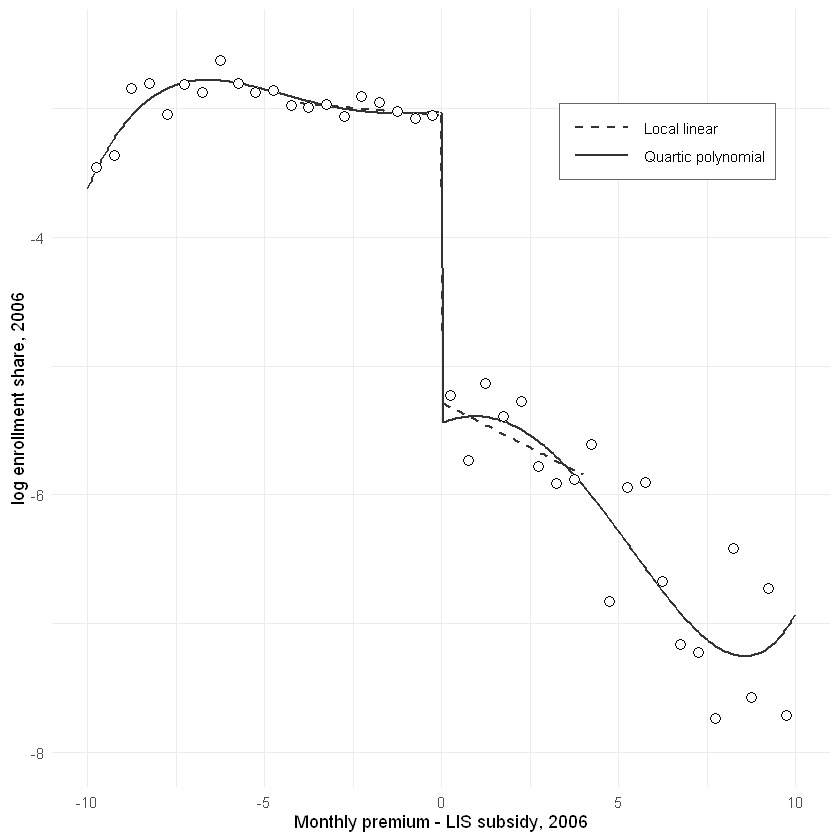

In [59]:
# Figure 3 replication-style fit: bins + local linear (h=4) + quartic (h=10)
# library(ggplot2)
# library(dplyr)
# library(fixest)
# library(grid)

# Build Figure 3 analysis sample
fig3 <- main_data %>%
  filter(year == 2006, benefit == "B") %>% # Limit to basic plans in 2006 (they come in 3 different forms BA, AE, DS)
  group_by(state, year) %>%
  mutate(
    stateYrEnroll = sum(enrollment, na.rm = TRUE),
    share = enrollment / stateYrEnroll,
    lnS = ifelse(share > 0, log(share), NA_real_)
  ) %>%
  ungroup() %>%
  mutate(
    LISPremium = premium - subsidy_amount, # Running variable: distance to cutoff (LIS subsidy) in 2006
    belowBench2006 = as.integer(LISPremium > 0),
    LISPremiumNeg = ifelse(LISPremium < 0, LISPremium, 0),
    LISPremiumPos = ifelse(LISPremium >= 0, LISPremium, 0),
    LISPremiumNegSq = LISPremiumNeg^2,
    LISPremiumPosSq = LISPremiumPos^2,
    LISPremiumNegCub = LISPremiumNeg^3,
    LISPremiumPosCub = LISPremiumPos^3,
    LISPremiumNegQuart = LISPremiumNeg^4,
    LISPremiumPosQuart = LISPremiumPos^4,
    # RD bandwidth flags around cutoff 0 in LISPremium:
    # RDwindow20061 keeps observations within +/-10 (wide window for bins/quartic).
    # RDwindow20062 keeps observations within +/-4 (narrow window for local-linear fit).
    RDwindow20061 = as.integer(abs(LISPremium) <= 10),
    RDwindow20062 = as.integer(abs(LISPremium) <= 4),
    side = ifelse(LISPremium < 0, "left", "right")
  )

# 0.50 bins for dots across full plotting window
step <- 0.5
fig3 <- fig3 %>%
  mutate(
    theBinAl = ifelse(
      LISPremium >= -10 & LISPremium <= 10,
      # Bin midpoint formula: floor(x/step) finds the bin index by rounding down to the lower bin boundary and then we multiply by step to get back to the bin boundary, and add step/2 to get to the midpoint.
      floor(LISPremium / step) * step + step / 2,
      # Use numeric NA outside plotting range so this column stays numeric in mutate().
      NA_real_
    )
  )

# Dots: local sample means by bin
fig3_bins <- fig3 %>%
  filter(RDwindow20061 == 1, !is.na(theBinAl), !is.na(lnS)) %>%
  group_by(theBinAl) %>%
  summarise(
    lnSHat = mean(lnS, na.rm = TRUE),
    n_bin = n(),
    side = ifelse(first(theBinAl) < 0, "left", "right"),
    .groups = "drop"
  )

# Dashed lines: local linear (h = 4) on raw data
m_lin <- feols(
  # belowBench2006 captures the jump at the cutoff (intercept shift).
  # LISPremiumNeg and LISPremiumPos allow different local slopes on each side.
  # Using only the indicator would force equal slopes left/right and can bias the RD jump.
  lnS ~ belowBench2006 + LISPremiumNeg + LISPremiumPos,
  data = fig3 %>% filter(RDwindow20062 == 1),
  vcov = ~ orgParentCode
 )

# Solid lines: quartic polynomial (h = 10) on raw data
# Per paper: smooth lines are polynomial approximations on raw observations;
# bins are used separately to plot local sample means (dots).
m_q <- feols(
  lnS ~ belowBench2006 + LISPremiumNeg + LISPremiumPos +
    LISPremiumNegSq + LISPremiumPosSq +
    LISPremiumNegCub + LISPremiumPosCub +
    LISPremiumNegQuart + LISPremiumPosQuart,
  data = fig3 %>% filter(RDwindow20061 == 1),
  vcov = ~ orgParentCode
 )

# Prediction grids by side to avoid connecting lines across cutoff
x_left_4 <- seq(-4, -0.001, by = 0.05)
x_right_4 <- seq(0, 4, by = 0.05)
x_left_10 <- seq(-10, -0.001, by = 0.05)
x_right_10 <- seq(0, 10, by = 0.05)

grid_lin <- bind_rows(
  tibble(LISPremium = x_left_4, side = "left"),
  tibble(LISPremium = x_right_4, side = "right")
 ) %>%
  mutate(
    belowBench2006 = as.integer(LISPremium > 0),
    LISPremiumNeg = ifelse(LISPremium < 0, LISPremium, 0),
    LISPremiumPos = ifelse(LISPremium >= 0, LISPremium, 0),
    spec = "Local linear"
  )
grid_lin$yhat <- predict(m_lin, newdata = grid_lin)

grid_q <- bind_rows(
  tibble(LISPremium = x_left_10, side = "left"),
  tibble(LISPremium = x_right_10, side = "right")
 ) %>%
  mutate(
    belowBench2006 = as.integer(LISPremium > 0),
    LISPremiumNeg = ifelse(LISPremium < 0, LISPremium, 0),
    LISPremiumPos = ifelse(LISPremium >= 0, LISPremium, 0),
    LISPremiumNegSq = LISPremiumNeg^2,
    LISPremiumPosSq = LISPremiumPos^2,
    LISPremiumNegCub = LISPremiumNeg^3,
    LISPremiumPosCub = LISPremiumPos^3,
    LISPremiumNegQuart = LISPremiumNeg^4,
    LISPremiumPosQuart = LISPremiumPos^4,
    spec = "Quartic polynomial"
  )
grid_q$yhat <- predict(m_q, newdata = grid_q)

plot_lines <- bind_rows(
  grid_lin %>% transmute(x = LISPremium, y = yhat, side, spec),
  grid_q %>% transmute(x = LISPremium, y = yhat, side, spec)
 )

fig3_plot <- ggplot() +
  geom_line(
    data = plot_lines,
    aes(x = x, y = y, linetype = spec, group = interaction(spec, side)),
    color = "grey20",
    linewidth = 0.8
  ) +
  geom_point(
    data = fig3_bins,
    aes(x = theBinAl, y = lnSHat),
    shape = 21,
    fill = "white",
    color = "black",
    stroke = 0.8,
    size = 2.6
  ) +
  scale_linetype_manual(values = c("Local linear" = "dashed", "Quartic polynomial" = "solid")) +
  scale_x_continuous(breaks = c(-10, -5, 0, 5, 10)) +
  coord_cartesian(xlim = c(-10, 10), ylim = c(-8, -2.5)) +
  labs(
    x = "Monthly premium - LIS subsidy, 2006",
    y = "log enrollment share, 2006",
    linetype = NULL
  ) +
  theme_minimal() +
  theme(
    legend.position = c(0.79, 0.83),
    legend.background = element_rect(fill = "white", color = "grey40", linewidth = 0.3),
    legend.key.width = unit(2.8, "lines")
  )

dir.create("../../Analysis_output", showWarnings = FALSE, recursive = TRUE)
ggsave("../../Analysis_output/Figure3.png", plot = fig3_plot, width = 7, height = 5, dpi = 300)

fig3_plot

### Ex. 3: Recreate Figure 3 from Ericson (2014) using two alternative sizes for the partition of the running variable: J=10, 30 (per side of cutoff)

In the paper notation (“dots are local averages with a bin size of $0.50”), they fix bin width and let the number of bins be implied by the x-range.

NOTE: 2 observations removed because of NA values (LHS: 2).

NOTE: 2 observations removed because of NA values (LHS: 2).

Saved: ../../Analysis_output/Figure3_J10.png

Saved: ../../Analysis_output/Figure3_J30.png



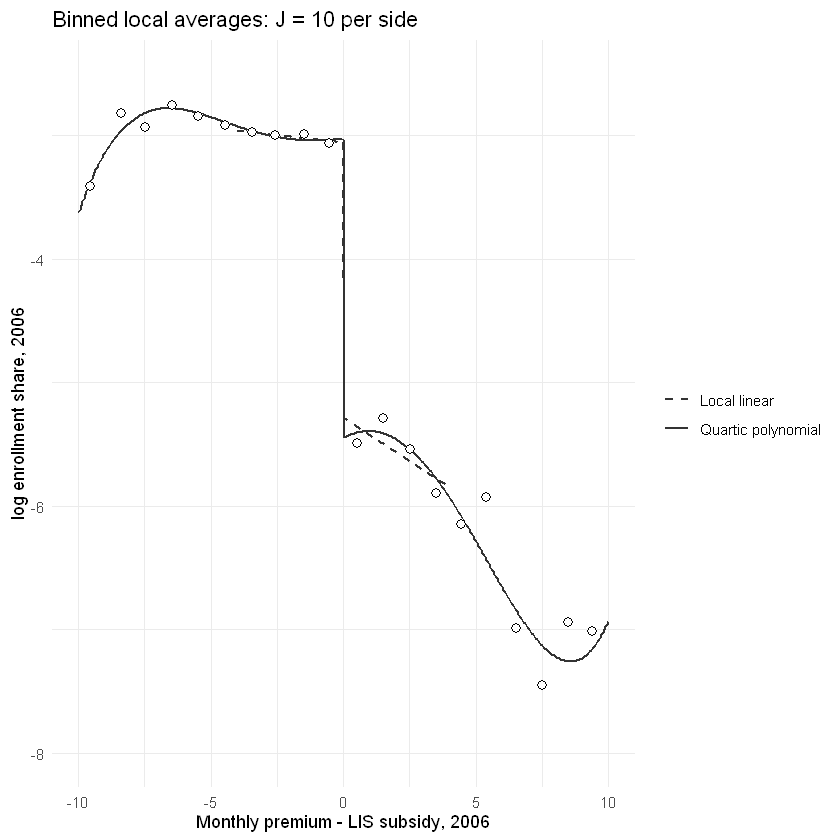

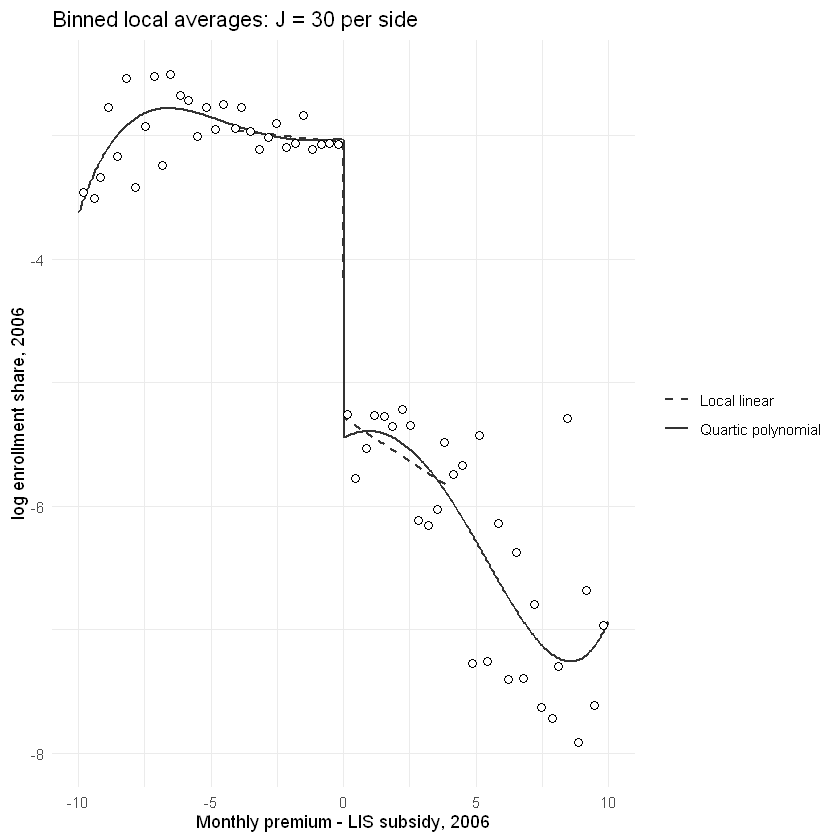

In [60]:
# Ex. 3: Partition-based bins with J per side + smoothing lines (as in Ex. 2)
library(dplyr)
library(ggplot2)
library(fixest)

# Build partition dots from paper notation:
# p_{-,j} = x_l + j * (xbar - x_l)/J and p_{+,j} = xbar + j * (x_u - xbar)/J
build_partition_dots <- function(df, J, x_l = -10, xbar = 0, x_u = 10) {
  left_breaks  <- x_l  + (0:J) * (xbar - x_l) / J
  right_breaks <- xbar + (0:J) * (x_u - xbar) / J

  dat <- df %>%
    filter(!is.na(LISPremium), !is.na(lnS), LISPremium >= x_l, LISPremium <= x_u) %>%
    mutate(
      bin = case_when(
        LISPremium < xbar ~ cut(LISPremium, breaks = left_breaks, include.lowest = TRUE, right = FALSE),
        LISPremium >= xbar ~ cut(LISPremium, breaks = right_breaks, include.lowest = TRUE, right = FALSE),
        TRUE ~ NA
      ),
      side = ifelse(LISPremium < xbar, "left", "right")
    )

  dat %>%
    group_by(side, bin) %>%
    summarise(
      x_dot = mean(LISPremium, na.rm = TRUE),
      y_dot = mean(lnS, na.rm = TRUE),
      n = n(),
      .groups = "drop"
    )
}

make_partition_plot <- function(df, J) {
  dots <- build_partition_dots(df, J = J)

  # Local linear fit with bandwidth h = 4 (dashed)
  m_lin <- feols(
    # belowBench2006 captures the jump at the cutoff (intercept shift).
    # LISPremiumNeg and LISPremiumPos allow different local slopes on each side.
    # Using only the indicator would force equal slopes left/right and can bias the RD jump.
    lnS ~ belowBench2006 + LISPremiumNeg + LISPremiumPos,
    data = df %>% filter(abs(LISPremium) <= 4),
    vcov = ~ orgParentCode
  )

  x_lin <- c(seq(-4, -0.001, by = 0.05), seq(0, 4, by = 0.05))
  grid_lin <- tibble(LISPremium = x_lin) %>%
    mutate(
      belowBench2006 = as.integer(LISPremium > 0),
      LISPremiumNeg = ifelse(LISPremium < 0, LISPremium, 0),
      LISPremiumPos = ifelse(LISPremium >= 0, LISPremium, 0),
      side = ifelse(LISPremium < 0, "left", "right"),
      spec = "Local linear"
    )
  grid_lin$yhat <- predict(m_lin, newdata = grid_lin)

  # Quartic fit with bandwidth h = 10 (solid)
  m_q <- feols(
    lnS ~ belowBench2006 + LISPremiumNeg + LISPremiumPos +
      LISPremiumNegSq + LISPremiumPosSq +
      LISPremiumNegCub + LISPremiumPosCub +
      LISPremiumNegQuart + LISPremiumPosQuart,
    data = df %>% filter(abs(LISPremium) <= 10),
    vcov = ~ orgParentCode
  )

  x_q <- c(seq(-10, -0.001, by = 0.05), seq(0, 10, by = 0.05))
  grid_q <- tibble(LISPremium = x_q) %>%
    mutate(
      belowBench2006 = as.integer(LISPremium > 0),
      LISPremiumNeg = ifelse(LISPremium < 0, LISPremium, 0),
      LISPremiumPos = ifelse(LISPremium >= 0, LISPremium, 0),
      LISPremiumNegSq = LISPremiumNeg^2,
      LISPremiumPosSq = LISPremiumPos^2,
      LISPremiumNegCub = LISPremiumNeg^3,
      LISPremiumPosCub = LISPremiumPos^3,
      LISPremiumNegQuart = LISPremiumNeg^4,
      LISPremiumPosQuart = LISPremiumPos^4,
      side = ifelse(LISPremium < 0, "left", "right"),
      spec = "Quartic polynomial"
    )
  grid_q$yhat <- predict(m_q, newdata = grid_q)

  lines <- bind_rows(
    grid_lin %>% transmute(x = LISPremium, y = yhat, side, spec),
    grid_q %>% transmute(x = LISPremium, y = yhat, side, spec)
  )

  ggplot() +
    geom_line(
      data = lines,
      aes(x = x, y = y, linetype = spec, group = interaction(spec, side)),
      color = "grey20",
      linewidth = 0.8
    ) +
    geom_point(
      data = dots,
      aes(x = x_dot, y = y_dot),
      shape = 21,
      fill = "white",
      color = "black",
      stroke = 0.8,
      size = ifelse(J <= 10, 2.4, 2.0)
    ) +
    scale_linetype_manual(values = c("Local linear" = "dashed", "Quartic polynomial" = "solid")) +
    scale_x_continuous(breaks = c(-10, -5, 0, 5, 10)) +
    coord_cartesian(xlim = c(-10, 10), ylim = c(-8, -2.5)) +
    labs(
      title = paste0("Binned local averages: J = ", J, " per side"),
      x = "Monthly premium - LIS subsidy, 2006",
      y = "log enrollment share, 2006",
      linetype = NULL
    ) +
    theme_minimal()
}

p10 <- make_partition_plot(fig3, J = 10)
p30 <- make_partition_plot(fig3, J = 30)

# Save both Ex. 3 figures on each run
dir.create("../../Analysis_output", showWarnings = FALSE, recursive = TRUE)
ggsave("../../Analysis_output/Figure3_J10.png", plot = p10, width = 7, height = 5, dpi = 300)
ggsave("../../Analysis_output/Figure3_J30.png", plot = p30, width = 7, height = 5, dpi = 300)

message("Saved: ../../Analysis_output/Figure3_J10.png")
message("Saved: ../../Analysis_output/Figure3_J30.png")

p10
p30

#### Discussion:



### Ex. 4: Recreate Figure 3 using the optimal number of partitions according to Calonico, Cattaneo, and Titiunik (2015) 

In [61]:
install.packages("rdrobust")
library(rdrobust)

# Find the optimal number of bins per side using the rdrobust package
rd_optimal <- rdrobust(
  y = fig3$lnS,
  x = fig3$LISPremium,
  c = 0,
  kernel = "triangular",
  vce = "hc1"
) 

rd_optimal_bins <- rd_optimal$N_h[1] # Optimal bins on the left side
rd_optimal_bins_right <- rd_optimal$N_h[2] # Optimal bins on the right side 
message("Optimal bins per side according to rdrobust: Left = ", rd_optimal_bins, ", Right = ", rd_optimal_bins_right)

Warning message:
"package 'rdrobust' is in use and will not be installed"
Optimal bins per side according to rdrobust: Left = 266, Right = 208



NOTE: 2 observations removed because of NA values (LHS: 2).

Saved: ../../Analysis_output/Figure3_JOptimal.png



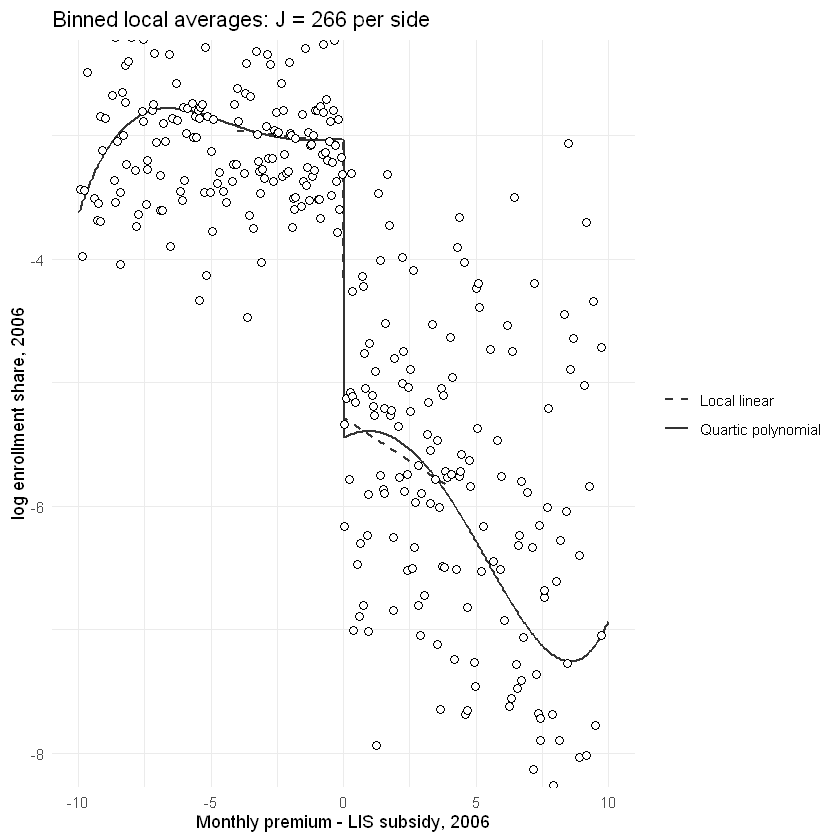

In [62]:
# Recreate Figure 3 using the optimal number of bins per side from rdrobust
p_optimal <- make_partition_plot(fig3, J = max(rd_optimal_bins, rd_optimal_bins_right))
# Why choosing the max of the two? Because we want to have the same number of bins on both sides for visual symmetry, 
# and using the maximum ensures we are not underfitting on either side.
dir.create("../../Analysis_output", showWarnings = FALSE, recursive = TRUE)
ggsave("../../Analysis_output/Figure3_JOptimal.png", plot = p_optimal, width = 7, height = 5, dpi = 300)
message("Saved: ../../Analysis_output/Figure3_JOptimal.png")  

p_optimal

### Ex. 5: Manipulation test based on Cattaneo, Jansson, and Ma (2018)

A manipulation test in this context is a hypothesis test on the continuity of the density f (·) at the cutoff point x.

In [63]:
install.packages("rddensity")
library(rddensity)

Warning message:
"package 'rddensity' is in use and will not be installed"


In [64]:
# Perform the density test around the cutoff using the rddensity package on the running variable (LISPremium) to check for manipulation around the cutoff.
density_test <- rddensity(
  X = fig3$LISPremium,
  c = 0,
  kernel = "triangular"
 )

print(density_test)
cat("Density discontinuity p-value (jackknife):", density_test$test$p_jk, "\n")
# Interpretation: with p = 0.0799, we do not reject continuity at the 5% level, so there is no clear evidence of manipulation/sorting at the cutoff.
# At the 10% level, this is marginal (weak) evidence of a discontinuity, not strong evidence.

Call:
rddensity.
Sample size: 821. Cutoff: 0.
Model: unrestricted. Kernel: triangular. VCE: jackknifeDensity discontinuity p-value (jackknife): 0.07986394 


### Ex. 6: Table 3 in Ericson (2014): Effect of LIS Benchmark Status in 2006 on Plan Enrollment 


In [82]:
# Table 3 setup: Panel A (local linear) and Panel B (quadratic), no covariates
library(fixest)

# 2006 treatment status and common RD window indicator
bench_2006 <- fig3 %>%
  distinct(uniqueID, belowBench2006, RDwindow20062)

# Build year-specific running variable terms, then lags used in later years
main_data_prep <- main_data %>%
  filter(benefit == "B") %>%
  left_join(bench_2006, by = "uniqueID") %>%
  mutate(
    LISPremium = premium - subsidy_amount,
    LISPremiumNeg = ifelse(LISPremium < 0, LISPremium, 0),
    LISPremiumPos = ifelse(LISPremium >= 0, LISPremium, 0),
    LISPremiumNegSq = LISPremiumNeg^2,
    LISPremiumPosSq = LISPremiumPos^2
  ) %>%
  arrange(uniqueID, year) %>%
  group_by(uniqueID) %>%
  mutate(
    L1LISPremiumNeg = lag(LISPremiumNeg, 1),
    L1LISPremiumPos = lag(LISPremiumPos, 1),
    L2LISPremiumNeg = lag(LISPremiumNeg, 2),
    L2LISPremiumPos = lag(LISPremiumPos, 2),
    L3LISPremiumNeg = lag(LISPremiumNeg, 3),
    L3LISPremiumPos = lag(LISPremiumPos, 3),
    L4LISPremiumNeg = lag(LISPremiumNeg, 4),
    L4LISPremiumPos = lag(LISPremiumPos, 4),
    L1LISPremiumNegSq = lag(LISPremiumNegSq, 1),
    L1LISPremiumPosSq = lag(LISPremiumPosSq, 1),
    L2LISPremiumNegSq = lag(LISPremiumNegSq, 2),
    L2LISPremiumPosSq = lag(LISPremiumPosSq, 2),
    L3LISPremiumNegSq = lag(LISPremiumNegSq, 3),
    L3LISPremiumPosSq = lag(LISPremiumPosSq, 3),
    L4LISPremiumNegSq = lag(LISPremiumNegSq, 4),
    L4LISPremiumPosSq = lag(LISPremiumPosSq, 4)
  ) %>%
  ungroup() %>%
  group_by(state, year) %>%
  mutate(
    stateYrEnroll = sum(enrollment, na.rm = TRUE),
    share = enrollment / stateYrEnroll,
    lnS = ifelse(share > 0, log(share), NA_real_)
  ) %>%
  ungroup()

# Formulas by year for Panel A (local linear)
year_specs_A <- list(
  `2006` = list(formula = "lnS ~ belowBench2006 + LISPremiumNeg + LISPremiumPos", neg = "LISPremiumNeg", pos = "LISPremiumPos"),
  `2007` = list(formula = "lnS ~ belowBench2006 + L1LISPremiumNeg + L1LISPremiumPos", neg = "L1LISPremiumNeg", pos = "L1LISPremiumPos"),
  `2008` = list(formula = "lnS ~ belowBench2006 + L2LISPremiumNeg + L2LISPremiumPos", neg = "L2LISPremiumNeg", pos = "L2LISPremiumPos"),
  `2009` = list(formula = "lnS ~ belowBench2006 + L3LISPremiumNeg + L3LISPremiumPos", neg = "L3LISPremiumNeg", pos = "L3LISPremiumPos"),
  `2010` = list(formula = "lnS ~ belowBench2006 + L4LISPremiumNeg + L4LISPremiumPos", neg = "L4LISPremiumNeg", pos = "L4LISPremiumPos")
)

# Formulas by year for Panel B (quadratic polynomial, no controls)
year_specs_B <- list(
  `2006` = "lnS ~ belowBench2006 + LISPremiumNeg + LISPremiumPos + LISPremiumNegSq + LISPremiumPosSq",
  `2007` = "lnS ~ belowBench2006 + L1LISPremiumNeg + L1LISPremiumPos + L1LISPremiumNegSq + L1LISPremiumPosSq",
  `2008` = "lnS ~ belowBench2006 + L2LISPremiumNeg + L2LISPremiumPos + L2LISPremiumNegSq + L2LISPremiumPosSq",
  `2009` = "lnS ~ belowBench2006 + L3LISPremiumNeg + L3LISPremiumPos + L3LISPremiumNegSq + L3LISPremiumPosSq",
  `2010` = "lnS ~ belowBench2006 + L4LISPremiumNeg + L4LISPremiumPos + L4LISPremiumNegSq + L4LISPremiumPosSq"
)

panel_A <- tibble(row = character(), yr = integer(), coef = numeric(), se = numeric(), nobs = integer(), r2 = numeric())
panel_B <- tibble(row = character(), yr = integer(), coef = numeric(), se = numeric(), nobs = integer(), r2 = numeric())

for (yr in 2006:2010) {
  yr_name <- as.character(yr)
  dat_yr <- main_data_prep %>% filter(year == yr, RDwindow20062 == 1, !is.na(lnS))

  # Panel A
  spec_A <- year_specs_A[[yr_name]]
  mod_A <- feols(as.formula(spec_A$formula), data = dat_yr, vcov = ~ orgParentCode)
  coefs_A <- coef(mod_A)
  ses_A <- se(mod_A)

  panel_A <- bind_rows(
    panel_A,
    tibble(row = "Below benchmark, 2006", yr = yr, coef = -coefs_A["belowBench2006"], se = ses_A["belowBench2006"], nobs = nobs(mod_A), r2 = r2(mod_A)),
    tibble(row = "Premium-subsidy, 2006 / Below benchmark", yr = yr, coef = coefs_A[spec_A$neg], se = ses_A[spec_A$neg], nobs = nobs(mod_A), r2 = r2(mod_A)),
    tibble(row = "Premium-subsidy, 2006 / Above benchmark", yr = yr, coef = coefs_A[spec_A$pos], se = ses_A[spec_A$pos], nobs = nobs(mod_A), r2 = r2(mod_A))
  )

  # Panel B
  mod_B <- feols(as.formula(year_specs_B[[yr_name]]), data = dat_yr, vcov = ~ orgParentCode)
  coefs_B <- coef(mod_B)
  ses_B <- se(mod_B)

  panel_B <- bind_rows(
    panel_B,
    tibble(row = "Below benchmark, 2006", yr = yr, coef = -coefs_B["belowBench2006"], se = ses_B["belowBench2006"], nobs = nobs(mod_B), r2 = r2(mod_B))
  )
}

invisible(NULL)

NOTE: 2 observations removed because of NA values (RHS: 2).

NOTE: 2 observations removed because of NA values (RHS: 2).



In [81]:
# Table 3 display: Panel A and Panel B only
library(gt)

star_label <- function(beta, se) {
  t_stat <- abs(beta / se)
  if (is.na(t_stat)) return("")
  if (t_stat > qnorm(0.995)) return("***")
  if (t_stat > qnorm(0.975)) return("**")
  if (t_stat > qnorm(0.95)) return("*")
  ""
}

fmt_coef <- function(beta, se, digits = 3) {
  paste0(sprintf(paste0("%.", digits, "f"), beta), star_label(beta, se), "\n(", sprintf(paste0("%.", digits, "f"), se), ")")
}

get_cell <- function(df, row_name, yr) {
  x <- df %>% filter(row == row_name, yr == !!yr)
  if (nrow(x) == 0) return("")
  fmt_coef(x$coef[1], x$se[1], 3)
}

get_n <- function(df, yr) {
  x <- df %>% filter(yr == !!yr)
  if (nrow(x) == 0) return("")
  as.character(x$nobs[1])
}

get_r2 <- function(df, yr) {
  x <- df %>% filter(yr == !!yr)
  if (nrow(x) == 0) return("")
  sprintf("%.3f", x$r2[1])
}

years <- 2006:2010

make_row <- function(label, vals) {
  tibble(
    Variable = label,
    Y2006 = vals[1],
    Y2007 = vals[2],
    Y2008 = vals[3],
    Y2009 = vals[4],
    Y2010 = vals[5]
  )
}

panel_a_header <- make_row("*Panel A. Local linear, bandwidth $4*", rep("", 5))
panel_a_below <- make_row("Below benchmark, 2006", sapply(years, function(y) get_cell(panel_A, "Below benchmark, 2006", y)))
panel_a_neg <- make_row("Premium-subsidy, 2006 / Below benchmark", sapply(years, function(y) get_cell(panel_A, "Premium-subsidy, 2006 / Below benchmark", y)))
panel_a_pos <- make_row("Premium-subsidy, 2006 / Above benchmark", sapply(years, function(y) get_cell(panel_A, "Premium-subsidy, 2006 / Above benchmark", y)))
panel_a_n <- make_row("Observations", sapply(years, function(y) get_n(panel_A, y)))
panel_a_r2 <- make_row("R2", sapply(years, function(y) get_r2(panel_A, y)))

panel_b_header <- make_row("*Panel B. Polynomial, bandwidth $4*", rep("", 5))
panel_b_below <- make_row("Below benchmark, 2006", sapply(years, function(y) get_cell(panel_B, "Below benchmark, 2006", y)))
panel_b_poly <- make_row("Premium-subsidy, 2006", rep("Quadratic", 5))
panel_b_n <- make_row("Observations", sapply(years, function(y) get_n(panel_B, y)))
panel_b_r2 <- make_row("R2", sapply(years, function(y) get_r2(panel_B, y)))

table3_display <- bind_rows(
  panel_a_header,
  panel_a_below,
  panel_a_neg,
  panel_a_pos,
  panel_a_n,
  panel_a_r2,
  make_row("", rep("", 5)),
  panel_b_header,
  panel_b_below,
  panel_b_poly,
  panel_b_n,
  panel_b_r2
)

tbl <- table3_display %>%
  gt(rowname_col = "Variable") %>%
  tab_header(
    title = "TABLE 3- EFFECT OF LIS BENCHMARK STATUS IN 2006 ON PLAN ENROLLMENT"
  ) %>%
  tab_spanner(label = "", columns = starts_with("Y")) %>%
  cols_label(
    Y2006 = "2006", Y2007 = "2007", Y2008 = "2008", Y2009 = "2009", Y2010 = "2010"
  ) %>%
  fmt_markdown(columns = c("Variable", starts_with("Y"))) %>%
  cols_align(align = "center", columns = starts_with("Y")) %>%
  cols_align(align = "left", columns = "Variable") %>%
  tab_footnote(
    footnote = "No covariates included. Standard errors in parentheses. Cluster-robust SEs at firm level. *** p<0.01, ** p<0.05, * p<0.10."
  ) %>%
  tab_options(
    table.font.size = px(11),
    heading.align = "center",
    column_labels.font.weight = "bold",
    table.border.top.style = "solid",
    table.border.bottom.style = "solid",
    heading.border.bottom.style = "solid"
  )

# Render clean inline HTML output
htmltools::HTML(gt::as_raw_html(tbl))

<div id="tdlbamidrv" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  
  <table class="gt_table" data-quarto-disable-processing="false" data-quarto-bootstrap="false" style="-webkit-font-smoothing: antialiased; -moz-osx-font-smoothing: grayscale; font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji'; display: table; border-collapse: collapse; line-height: normal; margin-left: auto; margin-right: auto; color: #333333; font-size: 11px; font-weight: normal; font-style: normal; background-color: #FFFFFF; width: auto; border-top-style: solid; border-top-width: 2px; border-top-color: #A8A8A8; border-right-style: none; border-right-width: 2px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #A8A8A8; border-left-style: none; border-left-width: 2px; border-left-color: #D3D3D3;" bgcolor="#FFFFFF">
  <thead style="border-style: none;">
    <tr class="gt_heading" style="border-style: none; background-color: #FFFFFF; text-align: center; border-bottom-color: #FFFFFF; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3;" bgcolor="#FFFFFF" align="center">
      <td colspan="6" class="gt_heading gt_title gt_font_normal gt_bottom_border" style="border-style: none; color: #333333; font-size: 125%; padding-top: 4px; padding-bottom: 4px; padding-left: 5px; padding-right: 5px; background-color: #FFFFFF; text-align: center; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; font-weight: normal;" bgcolor="#FFFFFF" align="center">TABLE 3- EFFECT OF LIS BENCHMARK STATUS IN 2006 ON PLAN ENROLLMENT</td>
    </tr>
    
    <tr class="gt_col_headings gt_spanner_row" style="border-style: none; border-top-style: solid; border-top-width: 2px; border-top-color: #D3D3D3; border-bottom-width: 2px; border-bottom-color: #D3D3D3; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; border-bottom-style: hidden;">
      <th class="gt_col_heading gt_columns_bottom_border gt_left" rowspan="2" colspan="1" scope="col" id="a::stub" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-right-style: none; border-right-width: 1px; border-right-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 6px; padding-left: 5px; padding-right: 5px; overflow-x: hidden; text-align: left;" bgcolor="#FFFFFF" valign="bottom" align="left"></th>
      <th class="gt_center gt_columns_top_border gt_column_spanner_outer" rowspan="1" colspan="5" scope="colgroup" style="border-style: none; color: #333333; background-color: #FFFFFF; font-size: 100%; font-weight: bold; text-transform: inherit; padding-top: 0; padding-bottom: 0; padding-left: 4px; text-align: center; padding-right: 0;" bgcolor="#FFFFFF" align="center">
        <div class="gt_column_spanner" style="border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; vertical-align: bottom; padding-top: 5px; padding-bottom: 5px; overflow-x: hidden; display: inline-block; width: 100%;"></div>
      </th>
    </tr>
    <tr class="gt_col_headings" style="border-style: none; border-top-style: solid; border-top-width: 2px; border-top-color: #D3D3D3; border-bottom-style: solid; border-bottom-width: 2px; border-bottom-color: #D3D3D3; border-left-style: none; border-left-width: 1px; border-left-color: #D3D3D3; border-righ